# Support Vector Machines (SVM)






# 1. Definición y Aplicaciones

## ¿Qué es un Support Vector Machine?

Un **Support Vector Machine (SVM)** es un algoritmo de aprendizaje supervisado que busca encontrar el **hiperplano óptimo** que separa dos clases en un espacio de características, maximizando el **margen** entre ellas.

Los puntos de datos más cercanos al hiperplano se llaman **vectores de soporte** (*support vectors*), y son los únicos que determinan la posición y orientación del hiperplano.

### Intuición visual

Imagina dos grupos de puntos en un plano. Hay infinitos rectas que los separan, pero SVM encuentra la recta que **maximiza la distancia** a los puntos más cercanos de cada clase.

## Aplicaciones reales

| Dominio | Aplicación |
|---|---|
| 🏥 Medicina | Diagnóstico de cáncer (benigno vs maligno) |
| 📧 Email | Filtros anti-spam |
| 💳 Finanzas | Detección de fraude en tarjetas |
| 🖼️ Visión artificial | Reconocimiento de imágenes y rostros |
| 📝 NLP | Clasificación de sentimientos |
| 🧬 Bioinformática | Clasificación de proteínas y genes |
| 🔤 OCR | Reconocimiento de texto manuscrito |

---
# 2. Fundamentos Matemáticos

## 2.1 El Hiperplano

Un **hiperplano** en $\mathbb{R}^n$ se define como:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

donde:
- $\mathbf{w} \in \mathbb{R}^n$ es el vector normal al hiperplano (pesos)
- $\mathbf{x} \in \mathbb{R}^n$ es el vector de características
- $b \in \mathbb{R}$ es el sesgo (*bias*)

La **distancia** de un punto $\mathbf{x}_i$ al hiperplano es:

$$d_i = \frac{|\mathbf{w}^T \mathbf{x}_i + b|}{\|\mathbf{w}\|}$$

## 2.2 Margen y Vectores de Soporte

Dado un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$ donde $y_i \in \{-1, +1\}$, definimos:

- **Hiperplano positivo:** $\mathbf{w}^T \mathbf{x} + b = +1$
- **Hiperplano negativo:** $\mathbf{w}^T \mathbf{x} + b = -1$
- **Margen geométrico:** $M = \dfrac{2}{\|\mathbf{w}\|}$

Los **vectores de soporte** son los puntos que satisfacen:
$$y_i (\mathbf{w}^T \mathbf{x}_i + b) = 1$$

## 2.3 Problema de Optimización (Hard Margin)

Maximizar el margen equivale a resolver:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2$$

$$\text{sujeto a:} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1, \quad \forall i = 1,\ldots,N$$

## 2.4 Soft Margin SVM (Variable de Holgura)

Para datos no perfectamente separables, introducimos variables de holgura $\xi_i \geq 0$:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^N \xi_i$$

$$\text{sujeto a:} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

donde $C > 0$ es el hiperparámetro de regularización que controla el trade-off entre margen máximo y errores de clasificación.

## 2.5 Función de Pérdida Hinge

El problema puede reescribirse usando la **pérdida hinge**:

$$L(\mathbf{w}) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{N}\sum_{i=1}^{N} \max\left(0,\, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)$$

Los **gradientes** para SGD son:

$$\frac{\partial L}{\partial \mathbf{w}} = \begin{cases} \lambda \mathbf{w} & \text{si } y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \\ \lambda \mathbf{w} - y_i \mathbf{x}_i & \text{si } y_i(\mathbf{w}^T \mathbf{x}_i + b) < 1 \end{cases}$$

## 2.6 El Truco del Kernel

Para problemas no linealmente separables, se mapean los datos a un espacio de mayor dimensión mediante:

$$\phi: \mathbb{R}^n \rightarrow \mathcal{H}$$

El **truco del kernel** evita calcular $\phi$ explícitamente usando funciones kernel:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

| Kernel | Fórmula |
|---|---|
| Lineal | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ |
| Polinomial | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i^T \mathbf{x}_j + r)^d$ |
| RBF (Gaussiano) | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma\|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$ |
| Sigmoide | $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma\, \mathbf{x}_i^T \mathbf{x}_j + r)$ |

---
# 3. SVM desde Cero

Implementaremos SVM lineal usando **Descenso de Gradiente Estocástico (SGD)** con pérdida hinge.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3f5c',
    'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#a0a0c0',
    'ytick.color': '#a0a0c0',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2d3e',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3f5c',
})

COLORS = {
    'class0': '#ff6b9d',
    'class1': '#4ecdc4',
    'margin': '#ffe66d',
    'hyperplane': '#ffffff',
    'sv': '#ff9f43',
    'accent': '#a29bfe',
}

print('✅ Librerías importadas correctamente')
print(f'   NumPy: {np.__version__}')

✅ Librerías importadas correctamente
   NumPy: 2.0.2


In [ ]:
# ============================================================
#  SVM DESDE CERO — Descenso de Gradiente Estocástico
# ============================================================

def svm_scratch_train(X, y, learning_rate=0.001, lambda_param=0.01, n_epochs=1000):
    """
    Entrena un SVM lineal usando SGD con pérdida Hinge.

    Parámetros
    ----------
    X            : array (N, d) — características
    y            : array (N,)  — etiquetas {-1, +1}
    learning_rate: float       — tasa de aprendizaje
    lambda_param : float       — regularización L2 (= 1/C)
    n_epochs     : int         — número de épocas

    Retorna
    -------
    w, b, loss_history
    """
    N, d = X.shape
    w = np.zeros(d)
    b = 0.0
    loss_history = []

    for epoch in range(n_epochs):
        # Shuffle para SGD
        idx = np.random.permutation(N)
        X_shuffled, y_shuffled = X[idx], y[idx]

        for xi, yi in zip(X_shuffled, y_shuffled):
            margin = yi * (np.dot(w, xi) + b)

            if margin >= 1:
                # Punto correctamente clasificado con margen suficiente
                w -= learning_rate * (lambda_param * w)
            else:
                # Violación de margen — actualización completa
                w -= learning_rate * (lambda_param * w - yi * xi)
                b += learning_rate * yi

        # Pérdida hinge promedio
        scores = y * (X @ w + b)
        hinge = np.maximum(0, 1 - scores).mean()
        reg = 0.5 * lambda_param * np.dot(w, w)
        loss_history.append(hinge + reg)

    return w, b, loss_history


def svm_scratch_predict(X, w, b):
    """Predice con el SVM entrenado. Retorna etiquetas {-1, +1}."""
    return np.sign(X @ w + b).astype(int)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


print('✅ Funciones SVM desde cero definidas')

✅ Funciones SVM desde cero definidas


In [ ]:
# ---- Generar dataset de prueba ----
np.random.seed(42)
X_raw, y_raw = make_blobs(n_samples=200, centers=2,
                           cluster_std=1.2, random_state=42)
y_raw = np.where(y_raw == 0, -1, 1)   # Convertir a {-1, +1}

# Escalar
scaler = StandardScaler()
X_raw  = scaler.fit_transform(X_raw)

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw,
                                            test_size=0.2, random_state=42)

# ---- Entrenar ----
w, b, loss_hist = svm_scratch_train(X_tr, y_tr,
                                    learning_rate=0.001,
                                    lambda_param=0.01,
                                    n_epochs=500)

y_pred_tr = svm_scratch_predict(X_tr, w, b)
y_pred_te = svm_scratch_predict(X_te, w, b)

print('='*50)
print('   RESULTADOS — SVM desde Cero')
print('='*50)
print(f'  Accuracy Train : {accuracy(y_tr, y_pred_tr):.4f}')
print(f'  Accuracy Test  : {accuracy(y_te, y_pred_te):.4f}')
print(f'  Pesos (w)      : {w}')
print(f'  Sesgo (b)      : {b:.4f}')

   RESULTADOS — SVM desde Cero
  Accuracy Train : 1.0000
  Accuracy Test  : 1.0000
  Pesos (w)      : [ 1.02750223 -0.86748845]
  Sesgo (b)      : 0.1440


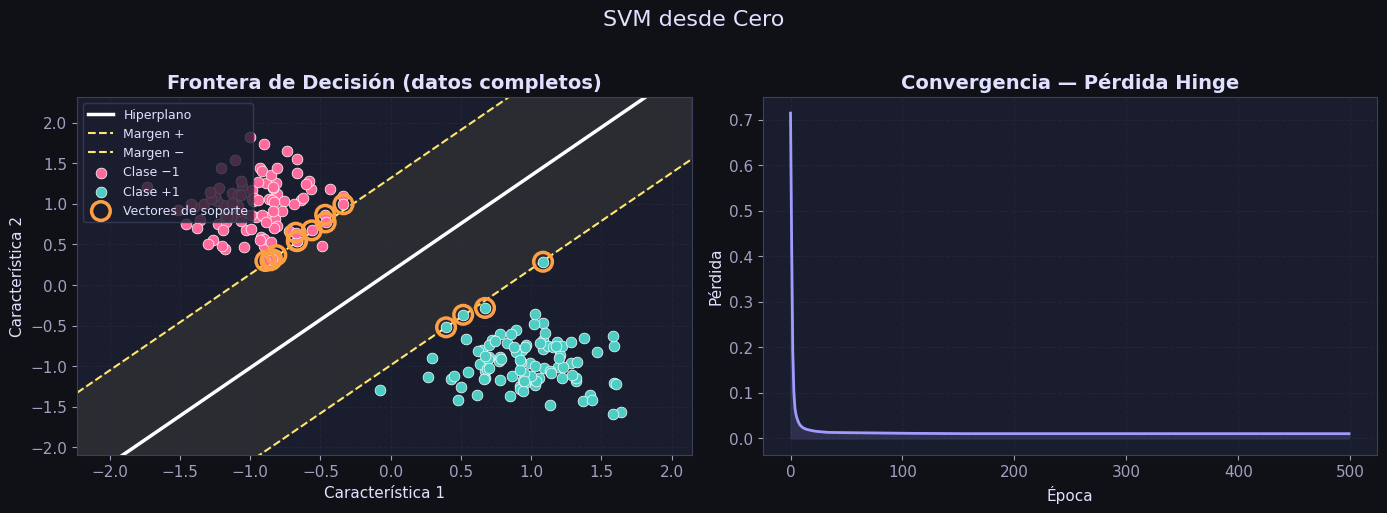

In [ ]:
def plot_decision_boundary_linear(X, y, w, b, title='SVM — Frontera de Decisión', ax=None):
    """Grafica frontera de decisión lineal y márgenes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx = np.linspace(x_min, x_max, 300)

    # Hiperplano principal
    if abs(w[1]) > 1e-10:
        yy       = -(w[0] * xx + b) / w[1]
        yy_pos   = -(w[0] * xx + b - 1) / w[1]
        yy_neg   = -(w[0] * xx + b + 1) / w[1]
        ax.plot(xx, yy,     color=COLORS['hyperplane'], lw=2.5, label='Hiperplano')
        ax.plot(xx, yy_pos, color=COLORS['margin'],     lw=1.5, ls='--', label='Margen +')
        ax.plot(xx, yy_neg, color=COLORS['margin'],     lw=1.5, ls='--', label='Margen −')
        ax.fill_between(xx, yy_pos, yy_neg,
                        alpha=0.08, color=COLORS['margin'])

    # Puntos
    mask0 = y == -1
    mask1 = y == +1
    ax.scatter(X[mask0, 0], X[mask0, 1], c=COLORS['class0'],
               edgecolors='white', linewidths=0.5, s=60, zorder=5, label='Clase −1')
    ax.scatter(X[mask1, 0], X[mask1, 1], c=COLORS['class1'],
               edgecolors='white', linewidths=0.5, s=60, zorder=5, label='Clase +1')

    # Vectores de soporte
    sv_mask = np.abs(y * (X @ w + b) - 1) < 0.15
    if sv_mask.any():
        ax.scatter(X[sv_mask, 0], X[sv_mask, 1],
                   s=180, facecolors='none',
                   edgecolors=COLORS['sv'], linewidths=2.5,
                   zorder=6, label='Vectores de soporte')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVM desde Cero', fontsize=16, y=1.02)

# Frontera de decisión
plot_decision_boundary_linear(X_raw, y_raw, w, b,
                               title='Frontera de Decisión (datos completos)',
                               ax=axes[0])

# Curva de pérdida
axes[1].plot(loss_hist, color=COLORS['accent'], lw=2)
axes[1].set_title('Convergencia — Pérdida Hinge')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida')
axes[1].grid(True)
axes[1].fill_between(range(len(loss_hist)), loss_hist,
                     alpha=0.15, color=COLORS['accent'])

plt.tight_layout()
plt.savefig('svm_scratch_resultado.png', dpi=120,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
# 4. Clase SVM Orientada a Objetos

Encapsulamos la implementación en una clase reutilizable siguiendo la API de Scikit-Learn (`fit`, `predict`, `score`).

In [ ]:
# ============================================================
#  CLASE SVM — Implementación OOP
# ============================================================

class SVMLineal:
    """
    Support Vector Machine Lineal (Soft Margin).
    Optimización mediante Descenso de Gradiente Estocástico con pérdida Hinge.

    Parámetros
    ----------
    C             : float  — parámetro de regularización (inversamente proporcional a lambda)
    learning_rate : float  — tasa de aprendizaje
    n_epochs      : int    — número de épocas de entrenamiento
    random_state  : int    — semilla aleatoria
    """

    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=1000, random_state=None):
        self.C = C
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state  = random_state
        self.w_ = None
        self.b_ = None
        self.loss_history_ = []
        self.classes_ = None

    def _encode_labels(self, y):
        """Convierte etiquetas a {-1, +1}."""
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError('SVMLineal solo soporta clasificación binaria.')
        return np.where(y == self.classes_[0], -1, 1).astype(float)

    def fit(self, X, y):
        """
        Entrena el modelo.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        X = np.array(X, dtype=float)
        y_enc = self._encode_labels(y)
        N, d  = X.shape
        lam = 1.0 / self.C

        self.w_ = np.zeros(d)
        self.b_ = 0.0
        self.loss_history_ = []

        for epoch in range(self.n_epochs):
            perm = np.random.permutation(N)
            Xp, yp = X[perm], y_enc[perm]

            for xi, yi in zip(Xp, yp):
                if yi * (np.dot(self.w_, xi) + self.b_) >= 1:
                    self.w_ -= self.learning_rate * lam * self.w_
                else:
                    self.w_ -= self.learning_rate * (lam * self.w_ - yi * xi)
                    self.b_ += self.learning_rate * yi

            # Registro de pérdida
            margins = y_enc * (X @ self.w_ + self.b_)
            hinge = np.maximum(0, 1 - margins).mean()
            reg = 0.5 * lam * np.dot(self.w_, self.w_)
            self.loss_history_.append(hinge + reg)

        return self

    def decision_function(self, X):
        """Devuelve los scores sin umbralizar."""
        return np.array(X, dtype=float) @ self.w_ + self.b_

    def predict(self, X):
        """Predice las clases originales."""
        signs = np.sign(self.decision_function(X))
        return np.where(signs < 0, self.classes_[0], self.classes_[1])

    def score(self, X, y):
        """Accuracy del modelo."""
        return np.mean(self.predict(X) == y)

    def __repr__(self):
        return (f'SVMLineal(C={self.C}, '
                f'learning_rate={self.learning_rate}, '
                f'n_epochs={self.n_epochs})')


print('✅ Clase SVMLineal definida')
print(SVMLineal())

✅ Clase SVMLineal definida
SVMLineal(C=1.0, learning_rate=0.001, n_epochs=1000)


In [ ]:
# ---- Probar la clase con el mismo dataset ----
# Convertir etiquetas a 0/1 (la clase maneja la conversión interna)
y_01 = np.where(y_raw == -1, 0, 1)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_raw, y_01,
                                                test_size=0.2, random_state=42)

# Probar distintos valores de C
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
results  = []

for C in C_values:
    svm = SVMLineal(C=C, learning_rate=0.001, n_epochs=500, random_state=42)
    svm.fit(X_tr2, y_tr2)
    acc_tr = svm.score(X_tr2, y_tr2)
    acc_te = svm.score(X_te2, y_te2)
    results.append({'C': C, 'Train Acc': acc_tr, 'Test Acc': acc_te,
                    'loss_final': svm.loss_history_[-1]})
    print(f'  C={C:6.2f}  |  Train: {acc_tr:.4f}  |  Test: {acc_te:.4f}')

print('\n✅ Comparativa completada')

In [ ]:
# ---- Visualizar frontera para distintos C ----

def plot_decision_boundary_class(model, X, y, ax, title=''):
    """Frontera de decisión para la clase SVMLineal."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf],
                colors=[COLORS['class0'], COLORS['class1']], alpha=0.15)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=[COLORS['margin'], COLORS['hyperplane'], COLORS['margin']],
               linewidths=[1.5, 2.5, 1.5], linestyles=['--', '-', '--'])

    mask0 = y == 0
    mask1 = y == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], c=COLORS['class0'], s=30,
               edgecolors='white', linewidths=0.3, zorder=5)
    ax.scatter(X[mask1, 0], X[mask1, 1], c=COLORS['class1'], s=30,
               edgecolors='white', linewidths=0.3, zorder=5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=11)
    ax.grid(True)


fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Efecto del Hiperparámetro C en la Frontera de Decisión', fontsize=14, y=1.02)

for ax, C in zip(axes, C_values):
    svm = SVMLineal(C=C, learning_rate=0.001, n_epochs=500, random_state=42)
    svm.fit(X_tr2, y_tr2)
    plot_decision_boundary_class(svm, X_raw, y_01, ax, title=f'C = {C}')

plt.tight_layout()
plt.savefig('svm_clase_C_comparativa.png', dpi=110,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
# 5. SVM con Scikit-Learn

Usaremos el dataset **Breast Cancer Wisconsin** (diagnóstico de cáncer de mama) — un caso real con 30 características y dos clases: *maligno* y *benigno*.

In [ ]:
# ============================================================
#  DATASET: Breast Cancer Wisconsin
# ============================================================

data = load_breast_cancer()
X_bc = data.data
y_bc = data.target   # 0 = maligno, 1 = benigno
labels = data.target_names

print(f'Dataset: {data.dataset_name if hasattr(data, "dataset_name") else "Breast Cancer Wisconsin"}')
print(f'Muestras  : {X_bc.shape[0]}')
print(f'Características: {X_bc.shape[1]}')
print(f'Clases    : {labels} → {np.bincount(y_bc)}')

# Preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)

scaler_bc  = StandardScaler()
X_train_sc = scaler_bc.fit_transform(X_train)
X_test_sc  = scaler_bc.transform(X_test)

print(f'\nTrain: {X_train.shape[0]} muestras')
print(f'Test : {X_test.shape[0]} muestras')

Dataset: Breast Cancer Wisconsin
Muestras  : 569
Características: 30
Clases    : ['malignant' 'benign'] → [212 357]

Train: 455 muestras
Test : 114 muestras


In [ ]:
# ============================================================
#  Comparar kernels en Breast Cancer
# ============================================================

kernels_config = {
    'Lineal':      SVC(kernel='linear',  C=1.0, random_state=42),
    'RBF':         SVC(kernel='rbf',     C=1.0, gamma='scale', random_state=42),
    'Polinomial':  SVC(kernel='poly',    C=1.0, degree=3,      random_state=42),
    'Sigmoide':    SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42),
}

kernel_results = {}

print(f'{"Kernel":<14} {"Train Acc":>12} {"Test Acc":>12}')
print('-' * 40)

for name, clf in kernels_config.items():
    clf.fit(X_train_sc, y_train)
    tr_acc = clf.score(X_train_sc, y_train)
    te_acc = clf.score(X_test_sc,  y_test)
    kernel_results[name] = {'train': tr_acc, 'test': te_acc, 'model': clf}
    print(f'{name:<14} {tr_acc:>12.4f} {te_acc:>12.4f}')

Kernel            Train Acc     Test Acc
----------------------------------------
Lineal               0.9912       0.9737
RBF                  0.9824       0.9825
Polinomial           0.9165       0.9123
Sigmoide             0.9560       0.9298


In [ ]:
# ---- Reporte detallado del mejor kernel (RBF) ----
best_clf  = kernel_results['RBF']['model']
y_pred_bc = best_clf.predict(X_test_sc)

print('\n' + '='*55)
print('   REPORTE DE CLASIFICACIÓN — SVM RBF (Breast Cancer)')
print('='*55)
print(classification_report(y_test, y_pred_bc,
                              target_names=labels))


   REPORTE DE CLASIFICACIÓN — SVM RBF (Breast Cancer)
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



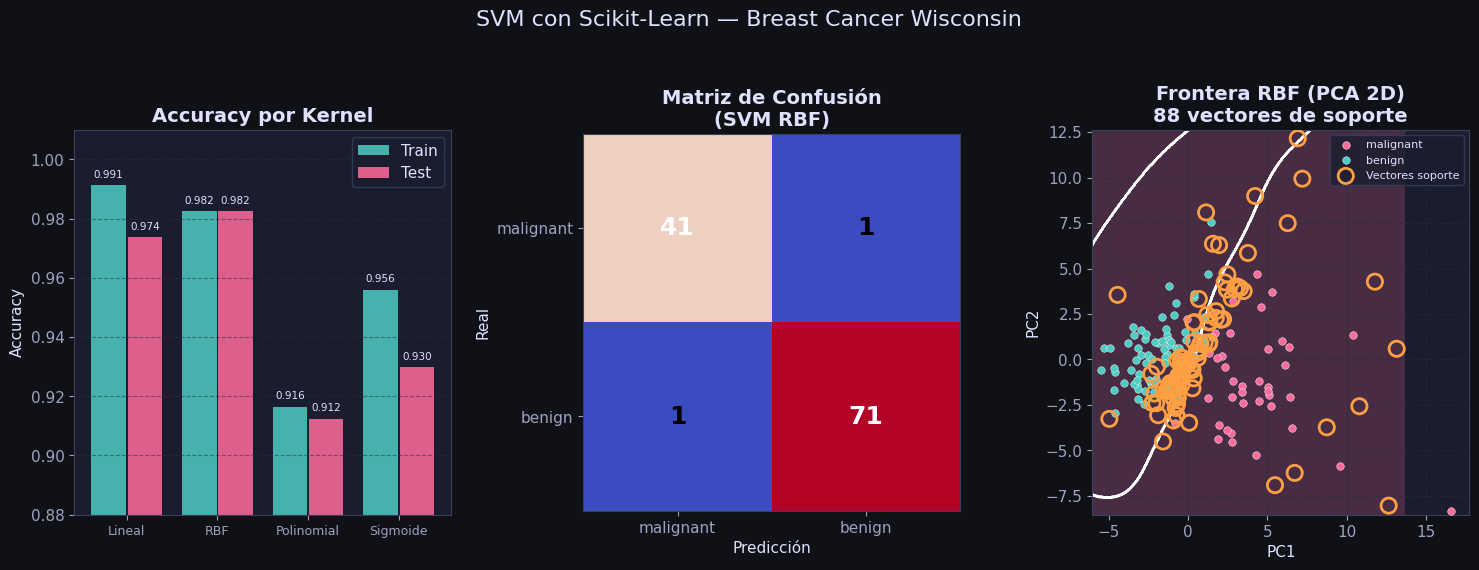

In [ ]:
# ============================================================
#  GRÁFICOS — Scikit-Learn SVM
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('SVM con Scikit-Learn — Breast Cancer Wisconsin', fontsize=16)
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ── 1. Comparativa de accuracy ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
names_k = list(kernel_results.keys())
train_acc = [kernel_results[k]['train'] for k in names_k]
test_acc  = [kernel_results[k]['test']  for k in names_k]
x_pos = np.arange(len(names_k))
bars1 = ax1.bar(x_pos - 0.2, train_acc, 0.38, label='Train',
                color=COLORS['class1'], alpha=0.85)
bars2 = ax1.bar(x_pos + 0.2, test_acc,  0.38, label='Test',
                color=COLORS['class0'], alpha=0.85)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names_k, fontsize=9)
ax1.set_ylim(0.88, 1.01)
ax1.set_title('Accuracy por Kernel')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, axis='y')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# ── 2. Matriz de confusión ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cm  = confusion_matrix(y_test, y_pred_bc)
im  = ax2.imshow(cm, cmap='coolwarm', interpolation='nearest')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=18, fontweight='bold',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)
ax2.set_title('Matriz de Confusión\n(SVM RBF)')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')

# ── 3. Frontera de decisión 2D (PCA → 2 componentes) ────────
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X_train_sc)
X_2d_te = pca.transform(X_test_sc)

clf_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf_2d.fit(X_2d, y_train)

ax3 = fig.add_subplot(gs[0, 2])
h   = 0.04
x_min2, x_max2 = X_2d[:, 0].min()-0.5, X_2d[:, 0].max()+0.5
y_min2, y_max2 = X_2d[:, 1].min()-0.5, X_2d[:, 1].max()+0.5
xx2, yy2 = np.meshgrid(np.arange(x_min2, x_max2, h),
                        np.arange(y_min2, y_max2, h))
Z2 = clf_2d.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
ax3.contourf(xx2, yy2, Z2, alpha=0.2,
             colors=[COLORS['class0'], COLORS['class1']])
ax3.contour(xx2, yy2, Z2, colors=[COLORS['hyperplane']], linewidths=1.5)
for cls, col, lbl in zip([0, 1], [COLORS['class0'], COLORS['class1']], labels):
    mask = y_test == cls
    ax3.scatter(X_2d_te[mask, 0], X_2d_te[mask, 1],
                c=col, s=30, edgecolors='white', lw=0.3,
                zorder=5, label=lbl)
sv = clf_2d.support_vectors_
ax3.scatter(sv[:, 0], sv[:, 1], facecolors='none',
            edgecolors=COLORS['sv'], linewidths=2, s=120, zorder=6,
            label='Vectores soporte')
ax3.set_title(f'Frontera RBF (PCA 2D)\n{clf_2d.n_support_.sum()} vectores de soporte')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.legend(fontsize=8)
ax3.grid(True)



plt.savefig('svm_sklearn_resultados.png', dpi=110,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()


---
# 6. Comparativa y Conclusiones

Comparamos las tres implementaciones en el mismo dataset.

In [ ]:
# ============================================================
#  COMPARATIVA FINAL — Scratch vs Clase vs Sklearn
# ============================================================

# Dataset binario estandarizado (blobs)
X_cmp, y_cmp = make_blobs(n_samples=300, centers=2,
                           cluster_std=1.2, random_state=42)
y_cmp_pm = np.where(y_cmp == 0, -1, 1)  # {-1, +1} para scratch

sc_cmp = StandardScaler()
X_cmp  = sc_cmp.fit_transform(X_cmp)

X_ctr, X_cte, y_ctr, y_cte = train_test_split(
    X_cmp, y_cmp, test_size=0.25, random_state=42)
_, _, y_ctr_pm, y_cte_pm = train_test_split(
    X_cmp, y_cmp_pm, test_size=0.25, random_state=42)

# ── 1. SVM Scratch ──────────────────────────────
w_c, b_c, lh_c = svm_scratch_train(X_ctr, y_ctr_pm,
                                    learning_rate=0.001,
                                    lambda_param=0.01,
                                    n_epochs=500)
pred_scratch_te = svm_scratch_predict(X_cte, w_c, b_c)
acc_scratch = np.mean(pred_scratch_te == y_cte_pm)

# ── 2. Clase SVMLineal ──────────────────────────
svm_clase = SVMLineal(C=100, learning_rate=0.001, n_epochs=500, random_state=42)
svm_clase.fit(X_ctr, y_ctr)
acc_clase = svm_clase.score(X_cte, y_cte)

# ── 3. Scikit-Learn (lineal) ────────────────────
svm_sk = SVC(kernel='linear', C=1.0)
svm_sk.fit(X_ctr, y_ctr)
acc_sk = svm_sk.score(X_cte, y_cte)

# ── Tabla comparativa ──────────────────────────
print('='*52)
print('   COMPARATIVA DE IMPLEMENTACIONES — Test Accuracy')
print('='*52)
print(f'  SVM desde Cero (SGD)    : {acc_scratch:.4f}')
print(f'  Clase SVMLineal (OOP)   : {acc_clase:.4f}')
print(f'  Scikit-Learn (lineal)   : {acc_sk:.4f}')
print('='*52)

   COMPARATIVA DE IMPLEMENTACIONES — Test Accuracy
  SVM desde Cero (SGD)    : 1.0000
  Clase SVMLineal (OOP)   : 1.0000
  Scikit-Learn (lineal)   : 1.0000


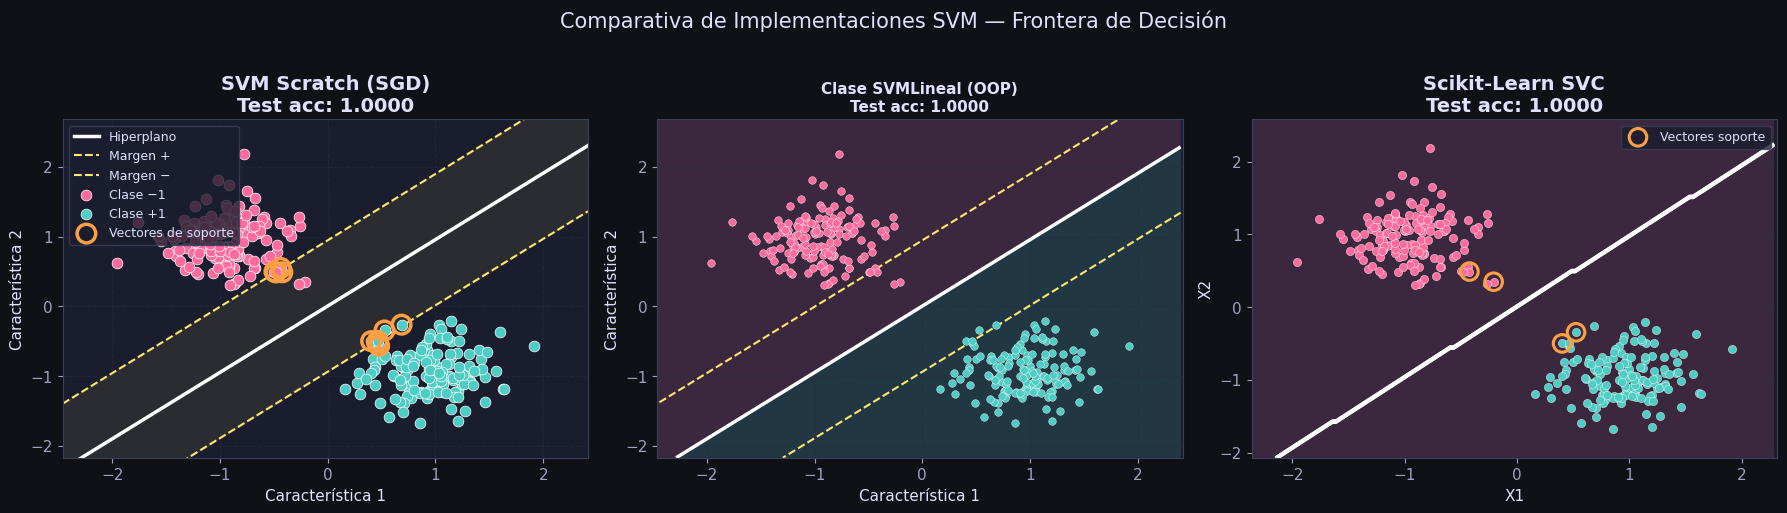

In [25]:
# ============================================================
#  GRÁFICO FINAL — Comparativa de fronteras
# ============================================================

def plot_decision_boundary_class(model, X, y, ax, title=''):
    """Frontera de decisión para la clase SVMLineal."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf],
                colors=[COLORS['class0'], COLORS['class1']], alpha=0.15)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=[COLORS['margin'], COLORS['hyperplane'], COLORS['margin']],
               linewidths=[1.5, 2.5, 1.5], linestyles=['--', '-', '--'])

    mask0 = y == 0
    mask1 = y == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], c=COLORS['class0'], s=30,
               edgecolors='white', linewidths=0.3, zorder=5)
    ax.scatter(X[mask1, 0], X[mask1, 1], c=COLORS['class1'], s=30,
               edgecolors='white', linewidths=0.3, zorder=5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.grid(True)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Implementaciones SVM — Frontera de Decisión',
             fontsize=15, y=1.02)

titles  = ['SVM Scratch (SGD)',  'Clase SVMLineal (OOP)', 'Scikit-Learn SVC']
accs    = [acc_scratch,           acc_clase,               acc_sk]

# Scratch
plot_decision_boundary_linear(
    X_cmp, y_cmp_pm, w_c, b_c,
    title=f'{titles[0]}\nTest acc: {accs[0]:.4f}',
    ax=axes[0])

# Clase
plot_decision_boundary_class(
    svm_clase, X_cmp,
    np.where(y_cmp_pm == -1, 0, 1),
    ax=axes[1],
    title=f'{titles[1]}\nTest acc: {accs[1]:.4f}')

# Sklearn
h  = 0.03
ax = axes[2]
xm, xM = X_cmp[:, 0].min()-0.4, X_cmp[:, 0].max()+0.4
ym, yM = X_cmp[:, 1].min()-0.4, X_cmp[:, 1].max()+0.4
xxs, yys = np.meshgrid(np.arange(xm, xM, h), np.arange(ym, yM, h))
Zs = svm_sk.predict(np.c_[xxs.ravel(), yys.ravel()]).reshape(xxs.shape)
ax.contourf(xxs, yys, Zs, alpha=0.15,
            colors=[COLORS['class0'], COLORS['class1']])
ax.contour(xxs, yys, Zs, colors=[COLORS['hyperplane']], linewidths=2)
for cls, col in zip([0, 1], [COLORS['class0'], COLORS['class1']]):
    m = y_cmp == cls
    ax.scatter(X_cmp[m, 0], X_cmp[m, 1], c=col,
               s=35, edgecolors='white', lw=0.3, zorder=5)
sv_sk = svm_sk.support_vectors_
ax.scatter(sv_sk[:, 0], sv_sk[:, 1],
           facecolors='none', edgecolors=COLORS['sv'],
           linewidths=2.2, s=160, zorder=6, label='Vectores soporte')
ax.set_title(f'{titles[2]}\nTest acc: {accs[2]:.4f}')
ax.set_xlabel('X1');  ax.set_ylabel('X2')
ax.legend(fontsize=9)
ax.grid(True)
ax.set_xlim(xm, xM);  ax.set_ylim(ym, yM)

plt.tight_layout()
plt.savefig('svm_comparativa_final.png', dpi=120,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()


---
# Conclusiones

| Aspecto | SVM Scratch | Clase OOP | Scikit-Learn |
|---|---|---|---|
| **Propósito** | Entender la teoría | Reutilización educativa | Producción |
| **Kernels** | Solo lineal | Solo lineal | Lineal, RBF, Poly, Sigmoid |
| **Optimización** | SGD manual | SGD manual | LibSVM (SMO) |
| **Velocidad** | Lenta | Lenta | Rápida |
| **Código** | ~30 líneas | ~80 líneas | 1 línea |

## Cuándo usar SVM

✅ **Recomendado cuando:**
- El dataset es pequeño o mediano (< 100k muestras)
- Hay muchas características (alta dimensionalidad)
- Las clases son claramente separables
- Se necesita un clasificador robusto con buena generalización

⚠️ **Con cautela cuando:**
- El dataset es muy grande (SVM escala como $O(N^2)$–$O(N^3)$)
- Las características no están escaladas
- Hay mucho ruido o superposición entre clases

---
*Notebook creado con NumPy, Matplotlib y Scikit-Learn*